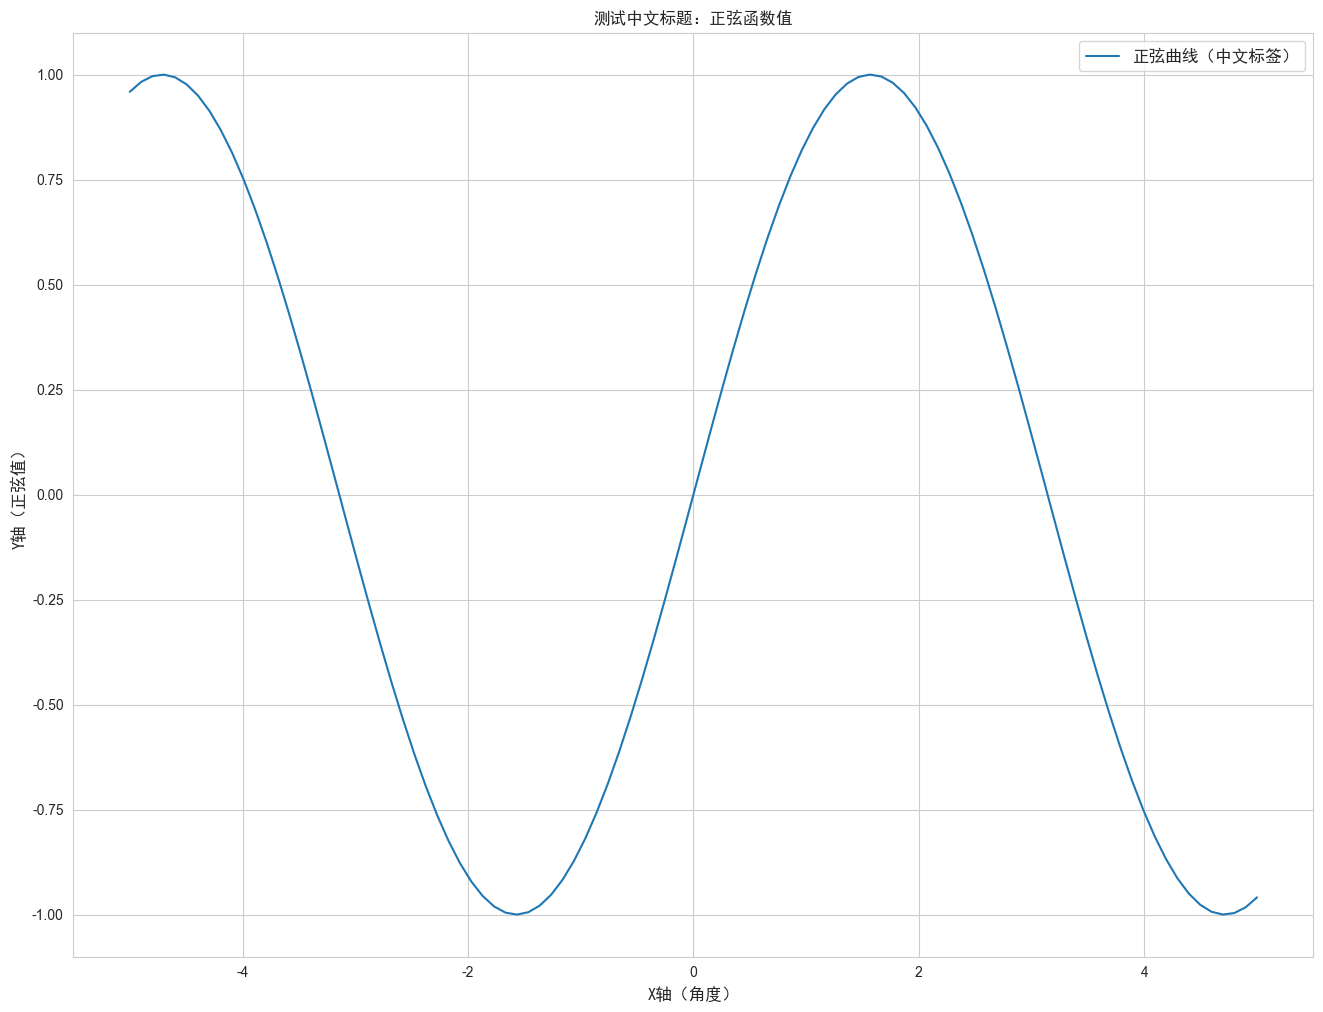

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
from scipy import stats


plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False  # 保证负号正常显示

# 1. 直接指定系统黑体字体文件路径（Windows 必存在）
# 路径是 Windows 系统默认的黑体字体位置，无需修改
font = FontProperties(
    fname=r'C:\Windows\Fonts\simhei.ttf',  # 黑体字体文件绝对路径
    size=12  # 字体大小，可根据需要调整
)
# 2. 解决负号显示问题（必须加）
plt.rcParams['axes.unicode_minus'] = False


sns.set_style("whitegrid")  # 图表样式
#给 seaborn 绘制的图表设置统一的 “风格主题”，让图表更美观、更易读。
#sns.set_style()：seaborn 的 “主题设置函数”，可以一键切换图表风格；
#"whitegrid"：“白色网格” 风格 —— 背景是白色，坐标轴有浅灰色网格线，既清晰又不杂乱
#"white"：纯白色背景，无网格（极简风）；"darkgrid"：深色背景 + 网格（适合对比强烈的图表）；
#"ticks"：带刻度线的风格（更严谨的学术风）。
plt.figure(figsize=(16, 12))
#设置整个画布的大小，避免图表挤在一起看不清。
#plt.figure()：创建一个 “画布”，所有后续的子图（比如饼图、柱状图）都画在这个画布上；
#figsize=(16, 12)：画布的宽度 = 16 英寸，高度 = 12 英寸（英寸是 matplotlib 的默认单位，1 英寸≈2.54 厘米）。
#

# 3. 测试绘图（所有中文文本都指定 fontproperties 参数）
x = np.linspace(-5, 5, 100)
y = np.sin(x)

plt.plot(x, y, label='正弦曲线（中文标签）')
plt.title('测试中文标题：正弦函数值', fontproperties=font)  # 指定字体
plt.xlabel('X轴（角度）', fontproperties=font)            # 指定字体
plt.ylabel('Y轴（正弦值）', fontproperties=font)          # 指定字体
plt.legend(prop=font)  # 图例也要指定字体
plt.grid(True)
plt.show()

In [2]:
# 2. 读取数据+补充特征名（KDD数据集核心）41个特征+1个标签
feature_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
]

# 读取20%训练集（替换成你的文件路径）
df = pd.read_csv("KDDTrain+_20Percent.txt", header=None)

# 关键：删除最后一列（难度值列，无业务意义）
# 因为原文件多了一列，所以df的列数是43，删掉最后一列恢复42列
df = df.iloc[:, :-1]  # iloc[:, :-1] = 保留所有行，保留除最后一列外的所有列

# 给42列赋特征名（此时列数和feature_names完全匹配）
df.columns = feature_names

# 验证读取是否成功（打印前3行）
print("数据读取成功！前3行数据：")
print(df.head(3))
print(f"删除难度值列后，数据维度：{df.shape}")  # 应该输出(25192, 42)

数据读取成功！前3行数据：
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                    0.60   
2                    0.10                    0.05   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                         0.17                          0.0   
1                         0.88                          0.0   
2                         0.00                          0.

In [3]:
# ====================== 3. 核心EDA分析 ======================
# 3.1 数据基本信息（类型+缺失值）
print("="*50)
print("1. 数据基本信息（维度+类型+缺失值）")
print("="*50)
print(f"数据维度（行×列）：{df.shape}")
print("\n数据类型 + 非空值统计：")
df.info()  # 查看每列类型、非空值数量（KDD数据集无缺失值，但需确认）

# 缺失值量化统计（百分比）
missing_rate = df.isnull().sum() / len(df) * 100
print("\n缺失值占比（按列）：")
print(missing_rate[missing_rate > 0] if any(missing_rate > 0) else "无缺失值")


1. 数据基本信息（维度+类型+缺失值）
数据维度（行×列）：(25192, 42)

数据类型 + 非空值统计：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised 

In [4]:
# 3.2 数值型特征统计描述（均值/中位数/分位数/异常值）
print("\n" + "="*50)
print("2. 数值型特征统计描述（识别异常值）")
print("="*50)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns #筛选所有数值型特征的列名
desc = df[numeric_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]) #通过describe()统计描述函数生产数值特征的详细统计报告
# count : 非空值数量(缺失) mean : 均值 std : 标准差(数据离散程度) min: 最小值 max: 最大值 percentiles: 补充分位数 
print(desc)

# 识别极端值（95分位数外的特征标记）
print("\n极端值特征（95分位数与最大值差异大）：")
for col in numeric_cols:
    q95 = df[col].quantile(0.95)
    max_val = df[col].max()
    if max_val > 2 * q95:  # 最大值是95分位数2倍以上，视为有极端值
        print(f"- {col}: 95分位数={q95:.2f}, 最大值={max_val:.2f}")



2. 数值型特征统计描述（识别异常值）
           duration     src_bytes     dst_bytes          land  wrong_fragment  \
count  25192.000000  2.519200e+04  2.519200e+04  25192.000000    25192.000000   
mean     305.054104  2.433063e+04  3.491847e+03      0.000079        0.023738   
std     2686.555640  2.410805e+06  8.883072e+04      0.008910        0.260221   
min        0.000000  0.000000e+00  0.000000e+00      0.000000        0.000000   
5%         0.000000  0.000000e+00  0.000000e+00      0.000000        0.000000   
25%        0.000000  0.000000e+00  0.000000e+00      0.000000        0.000000   
50%        0.000000  4.400000e+01  0.000000e+00      0.000000        0.000000   
75%        0.000000  2.790000e+02  5.302500e+02      0.000000        0.000000   
95%        5.000000  1.486450e+03  8.314000e+03      0.000000        0.000000   
max    42862.000000  3.817091e+08  5.151385e+06      1.000000        3.000000   

            urgent           hot  num_failed_logins     logged_in  \
count  25192.00000

In [5]:
# ======================
# 一级分类：特征数值类型（计数类/0-1二分类/比率类）+ 各自计算逻辑标识
# 二级分类：时序特征类型（增长型/周期型/稳定型）+ 各自计算逻辑标识
# 两者完全平行，互不嵌套，都有独立计算逻辑
# ======================
# 1. 一级分类（数值类型）：按数值特性划分，每类有专属计算逻辑
FIRST_LEVEL_CLASS = {
    # 计数类：非负整数，如字节数、次数、时长
    "count_type": [
        "duration", "src_bytes", "dst_bytes", "wrong_fragment", "urgent", "hot",
        "num_failed_logins", "num_compromised", "root_shell", "su_attempted",
        "num_root", "num_file_creations", "num_shells", "num_access_files",
        "count", "srv_count", "dst_host_count", "dst_host_srv_count"
    ],
    # 0/1二分类：仅0或1的布尔型特征
    "binary_type": [
        "root_shell", "su_attempted"  # 补充：根据NSL-KDD实际字段调整
    ],
    # 比率类：0-1之间的小数，如各类rate
    "ratio_type": [
        "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
        "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate",
        "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
    ]
}

# 2. 二级分类（时序类型）：按时序特性划分，每类有专属计算逻辑
SECOND_LEVEL_CLASS = {
    # 增长型：时序上有缓慢增长趋势
    "slow_growth": ["duration", "src_bytes", "dst_bytes"],
    # 周期型：时序上有周期性波动
    "cyclical": [
        "count", "srv_count", "dst_host_count", "dst_host_srv_count",
        "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate"
    ],
    # 稳定型：时序上无明显趋势/周期，波动小
    "stable": [
        "wrong_fragment", "urgent", "hot", "num_failed_logins", "num_compromised",
        "root_shell", "su_attempted", "num_root", "num_file_creations",
        "num_shells", "num_access_files", "same_srv_rate", "diff_srv_rate",
        "srv_diff_host_rate", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
        "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate",
        "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
    ]
}

# 3. 全量特征列表（去重）
ALL_FEATURES = list(set(
    [f for fs in FIRST_LEVEL_CLASS.values() for f in fs] +
    [f for fs in SECOND_LEVEL_CLASS.values() for f in fs]
))

# 4. 特征→分类映射（快速查询）
def get_feature_class(feature_name):
    """获取特征的一级+二级分类（平行返回）"""
    first_level = [k for k, v in FIRST_LEVEL_CLASS.items() if feature_name in v][0]
    second_level = [k for k, v in SECOND_LEVEL_CLASS.items() if feature_name in v][0]
    return first_level, second_level

# 验证映射（示例）
print("=== 分类映射验证（前5个特征）===")
for feat in ALL_FEATURES[:5]:
    f1, f2 = get_feature_class(feat)
    print(f"特征：{feat} | 一级（数值类型）：{f1} | 二级（时序类型）：{f2}")

=== 分类映射验证（前5个特征）===
特征：same_srv_rate | 一级（数值类型）：ratio_type | 二级（时序类型）：stable
特征：dst_host_same_src_port_rate | 一级（数值类型）：ratio_type | 二级（时序类型）：stable
特征：srv_serror_rate | 一级（数值类型）：ratio_type | 二级（时序类型）：cyclical
特征：root_shell | 一级（数值类型）：count_type | 二级（时序类型）：stable
特征：dst_host_serror_rate | 一级（数值类型）：ratio_type | 二级（时序类型）：stable


In [8]:
# 全局随机种子（结果可复现）
# np.random.seed(42)
# 查看数据基本信息
print(f"数值型特征示例（src_bytes前5行）：\n{df['src_bytes'].head()}")
print("所有列名：", df.columns.tolist())
print(f"标签分布：\n{df['label'].value_counts().head()}")

# --------------------------
# 1. 定义三类特征的显式逻辑
# --------------------------
class FeatureAnomalyAnalyzer:
    """
    整合版特征异常分析类：
    - 一级分类（数值类型）：count_type/binary_type/ratio_type → 专属预处理+阈值基础计算
    - 二级分类（时序类型）：slow_growth/cyclical/stable → 专属动态阈值调整
    - 0.05-0.95区间平稳度计算
    - 动态异常阈值（替代固定0.95）
    - 异常倍数分析（替代固定2倍max）
    - 兼容最初简化版逻辑
    """
    def __init__(self, df: pd.DataFrame, feature_name: str):
        """
        初始化特征分析器
        :param feature_data: 单特征的时间序列数据（pd.Series）
        :param feature_name: 要分析的特征名（如'src_bytes'/'dst_bytes'）
        """
        # 全局变量
        self.df = df
        self.feature_name = feature_name
        self.feature_data = df[feature_name].dropna() 
        
        # 平行获取一级+二级分类
        self.first_level, self.second_level = get_feature_class(feature_name)
        
        # 结果存储变量
        self.base_threshold = None
        self.stability_metrics = {}  # 存储平稳度指标
        self.simple_q95 = None  # 简化版固定阈值
        self.simple_normal_max = None  # 简化版正常max
        self.simple_anomalies = None  # 简化版异常值（2倍max过滤）
        self.dynamic_threshold = None  # 动态计算的异常阈值
        self.anomalies = None  # 异常值
        self.anomaly_multiples = None  # 异常倍数
    
    # --------------------------
    # 1.一级分类：数值类型专属计算逻辑
    # --------------------------
    def calculate_base_threshold(self):
        """根据一级分类（数值类型）计算基础阈值"""
        if self.first_level == "count_type":
            # 计数类：0.95分位数（非负整数特性）
            self.base_threshold = self.feature_data.quantile(0.95)
        elif self.first_level == "binary_type":
            # 0/1二分类：直接判定1为异常（布尔特性）
            self.base_threshold = 0.5  # 大于0.5即为1（异常）
        elif self.first_level == "ratio_type":
            # 比率类：0.9分位数（0-1区间特性，更严格）
            self.base_threshold = self.feature_data.quantile(0.9)
        return self.base_threshold
    
    
    # --------------------------
    # 最初简化版逻辑（固定0.95+2倍max）
    # --------------------------
    def simple_detect(self):
        """适配NSL-KDD的简化版异常检测"""
        # 0.95分位数阈值
        self.simple_q95 = self.feature_data.quantile(0.95)
        # 正常区间最大值
        self.simple_normal_max = self.feature_data[self.feature_data <= self.simple_q95].max()
        # 2倍max过滤异常值
        self.simple_anomalies = self.feature_data[
            (self.feature_data > self.simple_q95) & 
            (self.feature_data > 2 * self.simple_normal_max)
        ]
        return self.simple_anomalies

    
    # --------------------------
    # 2. 科研版：计算0.05-0.95分位数区间的平稳度（核心：用数据量化平稳性）
    # --------------------------
    def calculate_stability(self):
        """
        计算特征在0.05-0.95分位数区间的平稳度，核心指标：
        1. 变异系数（CV）：标准差/均值，越小越平稳
        2. 线性拟合残差方差：越小说明增长越线性（缓慢）
        3. 波动幅度：(95分位数-5分位数)/5分位数，越小越平稳
        """
        # 提取0.05-0.95分位数区间的数据
        q05 = self.feature_data.quantile(0.05)
        q95 = self.feature_data.quantile(0.95)
        mid_data = self.feature_data[(self.feature_data >= q05) & (self.feature_data <= q95)]
        
        # 指标1：变异系数（CV）
        cv = mid_data.std() / mid_data.mean() if mid_data.mean() != 0 else np.inf
        
        # 指标2：线性拟合残差方差
        residual_var = np.nan
        cycle_std = np.nan
        if self.second_level == 'slow_growth':
            # 增长型
            x = np.arange(len(mid_data))
            if len(x) >= 2 :
               slope, intercept, r_value, p_value, std_err = stats.linregress(x, mid_data)
               fitted = intercept + slope * x
               residual_var = np.var(mid_data - fitted)
        elif self.second_level == 'cyclical':
            # 周期型：滚动标准差均值（周期波动）
             cycle_std = self.feature_data.rolling(window=10).std().mean()
        
        # 指标3：相对波动幅度
        fluctuation = (q95 - q05) / q05 if q05 != 0 else np.inf
        
        # 存储指标
        self.stability_metrics = {
            'q05': q05,
            'q95': q95,
            '变异系数(CV)': cv,
            '线性残差方差': residual_var,
            '相对波动幅度': fluctuation,
            '周期波动均值': cycle_std,
            '区间数据量': len(mid_data)
        }
        return self.stability_metrics

    # --------------------------
    # 3. 基于平稳度动态计算异常阈值（替代固定0.95）
    # --------------------------
    def calculate_dynamic_threshold(self):
        """
        动态阈值逻辑：
        - 缓慢增长型：q95 + k*区间标准差（k根据CV调整，CV越小，k越小，阈值越接近q95）
        - 周期型：q95 + 2*周期波动幅度
        - 稳定型：q95 + 3*区间标准差
        """
        # 确保平稳度指标已计算
        if not hasattr(self, 'stability_metrics') or self.stability_metrics is None:
            self.calculate_stability()
        # 确保基础阈值已计算
        if not hasattr(self, 'base_threshold') or self.base_threshold is None:
            self.calculate_base_threshold()
        
        # 修复1：定义q95变量（从平稳度指标中获取）
        q95 = self.stability_metrics['q95']
        # 修复2：重新计算mid_data和mid_std（避免依赖外部变量）
        q05 = self.stability_metrics['q05']
        mid_data = self.feature_data[(self.feature_data >= q05) & (self.feature_data <= q95)]
        mid_std = mid_data.std() if len(mid_data) > 0 else 0  # 避免空数据报错
        
        #按特征类型动态调整k值
        if self.second_level== 'slow_growth':
            # 平稳度越高（CV越小），k越小，阈值越保守
            cv = self.stability_metrics['变异系数(CV)']
            k = 0.5 if cv < 0.1 else 1.0 if cv < 0.2 else 1.5
            # self.anomaly_threshold = q95 + k * mid_std
        elif self.second_level == 'cyclical':
            # 周期型特征：基于周期波动幅度
            cycle_fluctuation = self.stability_metrics['周期波动均值']
            # self.anomaly_threshold = q95 + 2 * cycle_fluctuation
            k=2.0
        elif self.second_level == 'stable':
            # 稳定型特征：更严格的阈值
            # self.anomaly_threshold = q95 + 3 * mid_std
            k=3.0

        self.dynamic_threshold = q95 + k * mid_std
        # 额外防护：避免动态阈值小于基础阈值
        self.dynamic_threshold = max(self.dynamic_threshold, self.base_threshold)
        
        return self.dynamic_threshold

    # --------------------------
    # 4. 检测异常值
    # --------------------------
    def detect_anomalies(self):
        """检测超过动态阈值的异常值+计算相对正常max的倍数"""
        if self.dynamic_threshold is None:
            self.calculate_dynamic_threshold()
        # 动态阈值异常值
        if self.first_level == "binary_type":
            self.anomalies = self.feature_data[self.feature_data > self.base_threshold]
        else:
            self.anomalies = self.feature_data[self.feature_data > self.dynamic_threshold]
        # 异常倍数，相对0.05-0.95区间max
        normal_max = self.feature_data[(self.feature_data>=self.stability_metrics['q05']) & (self.feature_data<=self.stability_metrics['q95'])].max()
        self.anomaly_multiples = self.anomalies / normal_max if normal_max != 0 else np.inf
        
        return self.anomalies, self.anomaly_multiples

    # --------------------------
    # 5. 可视化对比（简化版vs科研版）
    # --------------------------
    def plot_comparison(self):
        """可视化NSL-KDD特征异常检测结果 """
        font = FontProperties(
            fname=r'C:\Windows\Fonts\simhei.ttf',
            size=12
        )
        
        # 绘制特征数据分布（取1000个样本，避免图表有拥挤）
        plot_data = self.feature_data.head(1000)
        
        plt.plot(plot_data.index,plot_data.values,label=f'特征数据（{self.feature_name}）', color='grey',alpha=0.7)
        
        # 简化版阈值和异常值
        plt.axhline(y=self.simple_q95, color='orange', linestyle=':',label=f'简化版固定阈值: {self.simple_q95:.4f}')
        if self.simple_anomalies is not None and not self.simple_anomalies.empty:
            # 仅显示前1000个样本中的简化版异常值
            simple_anomalies_plot = self.simple_anomalies[self.simple_anomalies.index < 1000]
            plt.scatter(simple_anomalies_plot.index, simple_anomalies_plot.values,color='red',s=50,label='简化版异常值（2倍max）',zorder=5)
        
        # 科研版动态阈值和异常值
        plt.axhline(y=self.dynamic_threshold,color='blue',linestyle='--',label=f'二级阈值（{self.second_level}）：{self.dynamic_threshold:.4f}')
        plt.axhline(y=self.base_threshold,color='red',linestyle='-',label=f'一级阈值（{self.first_level}）：{self.base_threshold:.4f}')
        if self.anomalies is not None and not self.anomalies.empty:
            # 仅显示前1000个样本中的简化版异常值
            anomalies_plot = self.anomalies[self.anomalies.index < 1000]
            plt.scatter(anomalies_plot.index, anomalies_plot.values,color='green',s=30,label='科研版异常值',zorder=4)
        
        # 图表配置
        plt.title(f'特征{self.feature_name} | 一级：{self.first_level} | 二级：{self.second_level} 特征异常检测对比')
        plt.xlabel('样本索引')
        plt.ylabel(f'特征值')
        plt.legend()
        plt.grid(alpha=0.3)
        # 在plt.show()前添加保存语句
        plt.savefig(f'/mnt/feature_{self.feature_name}_plot.png', dpi=300, bbox_inches='tight')
        plt.close()  # 关闭图表，避免内存占用
        plt.show()
        
        
    # --------------------------
    # 结果汇总（所有特征验证）
    # --------------------------  
    def print_summary(self):
        """汇总打印双分类+检测结果"""
        print(f"\n=== 特征：{self.feature_name} ===")
        print(f"一级分类（数值类型）：{self.first_level}")
        print(f"二级分类（时序类型）：{self.second_level}")
        print(f"一级基础阈值：{self.base_threshold:.4f}")
        print(f"二级动态阈值：{self.dynamic_threshold:.4f}")
        print(f"异常值数量：{len(self.anomalies)}")
        print(f"异常倍数均值：{self.anomaly_multiples.mean():.2f}" if not self.anomaly_multiples.empty else "无异常值")

数值型特征示例（src_bytes前5行）：
0    491
1    146
2      0
3    232
4    199
Name: src_bytes, dtype: int64
所有列名： ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']
标签分布：
label
normal       13449
neptune       8282
ipsweep        710
satan          691
portsweep      587
Name: count, dtype: int64


开始批量验证所有特征（一级+二级分类）
待验证特征总数：33

【特征 1/33】
=== 最初简化版（固定0.95+2倍max）结果 ===
特征名：same_srv_rate
特征类型：('ratio_type', 'stable')
0.95分位数阈值：1.0000
正常区间最大值：1.0000
2倍max过滤后的异常值数量：0
异常值占比：0.00%
无异常值

=== 科研版（双分类+动态阈值）结果 ===

=== 特征：same_srv_rate ===
一级分类（数值类型）：ratio_type
二级分类（时序类型）：stable
一级基础阈值：1.0000
二级动态阈值：2.2998
异常值数量：0
无异常值

=== 0.05-0.95区间平稳度指标 ===
5分位数：0.0100
95分位数：1.0000
变异系数(CV)：0.6418
相对波动幅度：99.0000
区间数据量：24649

科研版异常值占比：0.01%

=== 可视化结果 ===


C:\Users\MSN\AppData\Local\Temp\ipykernel_21016\1770761734.py:227: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.savefig(f'/mnt/feature_{self.feature_name}_plot.png', dpi=300, bbox_inches='tight')
C:\Users\MSN\AppData\Local\Temp\ipykernel_21016\1770761734.py:227: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.savefig(f'/mnt/feature_{self.feature_name}_plot.png', dpi=300, bbox_inches='tight')
C:\Users\MSN\AppData\Local\Temp\ipykernel_21016\1770761734.py:227: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) Arial.
  plt.savefig(f'/mnt/feature_{self.feature_name}_plot.png', dpi=300, bbox_inches='tight')
C:\Users\MSN\AppData\Local\Temp\ipykernel_21016\1770761734.py:227: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) Arial.
  plt.savefig(f'/mnt/feature_{self.feature_name}_plot.png', dpi=300, bbox_inches='tight')
C:\Users\MSN\AppData\Local\T

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\mnt\\feature_same_srv_rate_plot.png'

D:\python_item\ML_ids_py3.12\g-qusz7812-ml_ids-ml_ids-\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\python_item\ML_ids_py3.12\g-qusz7812-ml_ids-ml_ids-\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\python_item\ML_ids_py3.12\g-qusz7812-ml_ids-ml_ids-\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\python_item\ML_ids_py3.12\g-qusz7812-ml_ids-ml_ids-\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\python_item\ML_ids_py3.12\g-qusz7812-ml_ids-ml_ids-\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 29305 (\N{C

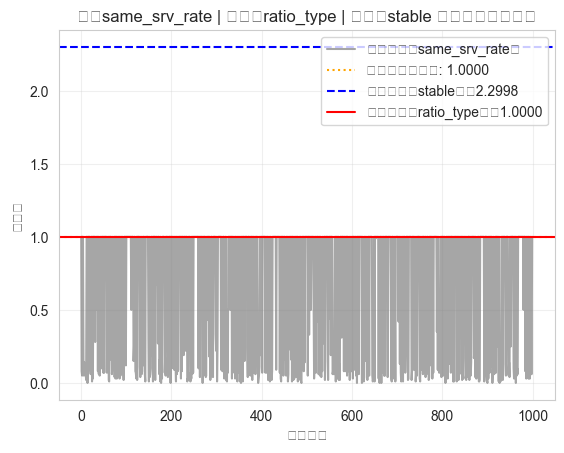

In [10]:
# ======================
# 批量验证所有特征（无遗漏）
# ======================
if __name__ == '__main__':

  # 2. 模拟测试数据（快速验证，实际使用时删除）
  #   np.random.seed(42)
  #   df = pd.DataFrame()
  #   for feat in ALL_FEATURES:
  #       f1, _ = get_feature_class(feat)
  #       if f1 == "count_type":
  #           df[feat] = np.random.poisson(lam=10, size=1000)  # 计数类
  #       elif f1 == "binary_type":
  #           df[feat] = np.random.choice([0, 1], size=1000, p=[0.95, 0.05])  # 二分类
  #       elif f1 == "ratio_type":
  #           df[feat] = np.random.uniform(0, 1, size=1000)  # 比率类
    
    # 3. 批量分析所有特征
    print("="*80)
    print("开始批量验证所有特征（一级+二级分类）")
    print(f"待验证特征总数：{len(ALL_FEATURES)}")
    print("="*80)
    
    # 新增：记录所有特征的异常统计结果
    anomaly_summary = []
  
    # 可视化开关：建议批量验证时仅对异常多的特征可视化，或按需开启
    PLOT_SWITCH = True  # True=开启可视化，False=关闭
    
    for idx,feat in enumerate(ALL_FEATURES,1):
        print(f"\n【特征 {idx}/{len(ALL_FEATURES)}】")
        # 初始化分析器
        analyzer = FeatureAnomalyAnalyzer(df, feat)
        
        simple_anomalies = analyzer.simple_detect()
        print("=== 最初简化版（固定0.95+2倍max）结果 ===")
        print(f"特征名：{analyzer.feature_name}")
        print(f"特征类型：{get_feature_class(feat)}")  # 新增：输出特征类型，便于分类验证
        print(f"0.95分位数阈值：{analyzer.simple_q95:.4f}")
        print(f"正常区间最大值：{analyzer.simple_normal_max:.4f}")
        print(f"2倍max过滤后的异常值数量：{len(simple_anomalies)}")
        print(f"异常值占比：{len(simple_anomalies)/len(df)*100:.2f}%")  # 新增：异常值占比，更直观
        if len(simple_anomalies) > 0:
            print(f"异常值示例（前5个）：\n{simple_anomalies.head()}\n")
        else:
            print("无异常值\n")  # 新增：无异常时明确提示，避免输出空值
            
        # 执行所有计算逻辑
        analyzer.calculate_base_threshold()
        stability_metrics = analyzer.calculate_stability()  # 接收返回的平稳度指标
        analyzer.calculate_dynamic_threshold()  # 已修复，可正常运行
        anomalies = analyzer.detect_anomalies()
        
        print("=== 科研版（双分类+动态阈值）结果 ===")
        # 调用print_summary，无需重复输出已包含的内容
        analyzer.print_summary()
        # 修复：正确读取calculate_stability的所有平稳度指标
        print("\n=== 0.05-0.95区间平稳度指标 ===")
        print(f"5分位数：{stability_metrics['q05']:.4f}")
        print(f"95分位数：{stability_metrics['q95']:.4f}")
        print(f"变异系数(CV)：{stability_metrics['变异系数(CV)']:.4f}")
        print(f"相对波动幅度：{stability_metrics['相对波动幅度']:.4f}")
        print(f"区间数据量：{stability_metrics['区间数据量']}")
        # 按需输出特定类型的指标
        if not np.isnan(stability_metrics['线性残差方差']):
            print(f"线性拟合残差方差：{stability_metrics['线性残差方差']:.4f}")
        if not np.isnan(stability_metrics['周期波动均值']):
            print(f"周期波动均值（滚动10窗）：{stability_metrics['周期波动均值']:.4f}")
        
        print(f"\n科研版异常值占比：{len(anomalies)/len(df)*100:.2f}%")
        
        
        # 记录汇总信息（包含所有平稳度核心指标）
        anomaly_summary.append({
            "feature_name": feat,
            "first_level_type": analyzer.first_level,
            "second_level_type": analyzer.second_level,
            "base_threshold": analyzer.base_threshold,
            "dynamic_threshold": analyzer.dynamic_threshold,
            "simple_anomaly_count": len(simple_anomalies),
            "dynamic_anomaly_count": len(analyzer.anomalies),
            "anomaly_multiples_mean": analyzer.anomaly_multiples.mean() if not analyzer.anomaly_multiples.empty else 0,
            # 平稳度核心指标
            "cv": stability_metrics['变异系数(CV)'],
            "fluctuation": stability_metrics['相对波动幅度'],
            "mid_data_count": stability_metrics['区间数据量']
        })
        # ========== 整合可视化函数 ==========
        # 优化：可按需开启（比如仅异常值>0时可视化）
        if PLOT_SWITCH and (len(simple_anomalies) > 0 or len(anomalies) > 0):
            print("\n=== 可视化结果 ===")
            analyzer.plot_comparison()
        
        print("-"*50)
      
      
    # 批量验证完成后输出汇总表格
    print("\n" + "="*80)
    print("所有特征验证汇总（含双分类+阈值+异常+平稳度）")
    print("="*80)
    summary_df = pd.DataFrame(anomaly_summary)
    # 调整列顺序并美化列名
    summary_df = summary_df[[
        "feature_name", "first_level_type", "second_level_type",
        "base_threshold", "dynamic_threshold",
        "cv", "fluctuation", "mid_data_count",
        "simple_anomaly_count", "dynamic_anomaly_count", "anomaly_multiples_mean"
    ]]
    # 重命名列名，更易读
    summary_df.rename(columns={
        "cv": "变异系数(CV)",
        "fluctuation": "相对波动幅度",
        "mid_data_count": "0.05-0.95区间数据量"
    }, inplace=True)
    print(summary_df.round(4))  # 统一保留4位小数

    # 可选：保存汇总结果到CSV
    # summary_df.to_csv("feature_anomaly_summary.csv", index=False)
    # print("\n汇总结果已保存到 feature_anomaly_summary.csv")

In [ ]:
# 3.3 分类特征分布（协议/服务/标签）
print("\n" + "="*50)
print("3. 分类特征分布（核心业务维度）")
print("="*50)
# 3.3.1 协议类型分布
print("\n(1) 协议类型（protocol_type）分布：")
proto_dist = df['protocol_type'].value_counts()
print(proto_dist)

# 3.3.2 攻击标签分布（核心！区分正常/攻击）
print("\n(2) 标签（正常/攻击）分布：")
label_dist = df['label'].value_counts()
print(label_dist)
# 简化标签：normal=正常，其他=攻击（二分类视角）
df['label_simple'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
print("\n简化标签（正常/攻击）分布：")
print(df['label_simple'].value_counts())


In [ ]:

# 3.4 可视化分析（核心分布+关联）
print("\n" + "="*50)
print("4. 可视化分析（分布+关联）")
print("="*50)

# 4.1 标签分布可视化（正常vs攻击）
plt.subplot(2, 2, 1)
df['label_simple'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                       colors=['#66b3ff', '#ff9999'], explode=[0, 0.1])
plt.title('标签分布（正常vs攻击）', fontsize=12)
plt.ylabel('')

# 4.2 协议类型分布（top5）
plt.subplot(2, 2, 2)
df['protocol_type'].value_counts().plot(kind='bar', color='#87CEEB')
plt.title('协议类型分布', fontsize=12)
plt.xlabel('协议类型')
plt.ylabel('数量')

# 4.3 数值特征异常值可视化（src_bytes箱线图）
plt.subplot(2, 2, 3)
# 取src_bytes前1%分位数内的数据（避免极端值掩盖分布）
src_bytes_filtered = df[df['src_bytes'] < df['src_bytes'].quantile(0.99)]
sns.boxplot(x='label_simple', y='src_bytes', data=src_bytes_filtered)
plt.title('正常/攻击流量的源字节数分布', fontsize=12)
plt.xlabel('标签')
plt.ylabel('源字节数（过滤极端值）')

# 4.4 核心数值特征相关性热力图（前10个数值特征）
plt.subplot(2, 2, 4)
corr_cols = numeric_cols[:10]  # 选前10个避免图太密
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('核心数值特征相关性热力图', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# 3.5 攻击类型细分分布（top10）
print("\n(3) 攻击类型TOP10分布：")
top10_attack = df[df['label'] != 'normal']['label'].value_counts().head(10)
print(top10_attack)

# 可视化TOP5攻击类型
plt.figure(figsize=(10, 6))
top5_attack = top10_attack.head(5)
top5_attack.plot(kind='bar', color='#ff7f0e')
plt.title('TOP5攻击类型分布', fontsize=12)
plt.xlabel('攻击类型')
plt.ylabel('数量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()